In [1]:
import numpy as np
import torch
import os
import sys

![image](../poster.png)

image shape: (106, 100, 100, 3) pose shape: (106, 4, 4) focal length: 138.88887889922103


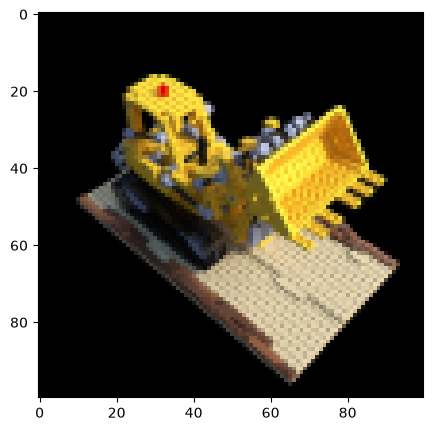

In [2]:
## Load images
data = np.load('/root/project/data/tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
test_image, test_pose = images[101], poses[101]
print('image shape:', images.shape, 'pose shape:', poses.shape, 'focal length:', focal)
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(test_image)

In [ ]:
## rays
def get_rays(H, W, focal, c2w):
    i, j = np.meshgrid(np.arange(W), np.arange(H), indexing='xy')
    dirs = np.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -np.ones_like(i)], axis=-1)
    rays_d = np.sum(dirs[..., np.newaxis, :] * c2w[:3, :3], axis=-1)
    print('rays_d :', (dirs[..., np.newaxis, :]*c2w[:3, :3]).shape, rays_d.shape)
    rays_o = np.broadcast_to(c2w[:3, -1], np.shape(rays_d))
    return rays_o, rays_d

def render_rays(rays_o, rays_d, near, far, num_samples):
    t_vals = np.linspace(near, far, num_samples)
    t_vals = np.broadcast_to(t_vals, list(rays_o.shape[:-1]) + [num_samples])
    pts = rays_o[..., None, :] + rays_d[..., None, :] * t_vals[..., :, None]
    return pts

In [24]:
import torch.nn as nn
class NeRFMLP(nn.Module):
    def __init__(self, input_dim, layers, hidden_dim, skip_layer, output_dim):
        super(NeRFMLP, self).__init__()

        self.skip_layer = skip_layer
        self.linears = nn.ModuleList()
        for i in range(layers):
            if i == 0:
                self.linears.append(nn.Linear(input_dim, hidden_dim))
            elif i == skip_layer:
                self.linears.append(nn.Linear(hidden_dim + input_dim, hidden_dim))
            else:
                self.linears.append(nn.Linear(hidden_dim, hidden_dim))
        self.output_linear = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
    def forward(self, x):
        input = x
        for i, layer in enumerate(self.linears):
            if i == self.skip_layer:
                x = torch.cat([x, input], dim=-1)
            x = self.relu(layer(x))
        return self.output_linear(x)

In [ ]:
import torch
gaussian_params = torch.load('../models_smoke/block_z000_y001_x006/best.pth')
# 3D gaussian formula to reconstruct the volume by params
def reconstruct_volume(gaussian_params, pts):
    # Extract parameters from gaussian_params
    means = gaussian_params['means']  # Shape: (num_gaussians, 3)
    covariances = gaussian_params['covariances']  # Shape: (num_gaussians, 3, 3)
    weights = gaussian_params['weights']  # Shape: (num_gaussians,)

    # Compute the volume density at each point in pts
    volume_density = torch.zeros(pts.shape[:-1], device=pts.device)

    for i in range(means.shape[0]):
        mean = means[i]
        covariance = covariances[i]
        weight = weights[i]

        # Compute the multivariate Gaussian density
        diff = pts - mean
        exponent = -0.5 * torch.sum(diff @ torch.inverse(covariance) * diff, dim=-1)
        normalization = torch.sqrt((2 * torch.pi) ** 3 * torch.det(covariance))
        gaussian_density = weight * torch.exp(exponent) / normalization

        volume_density += gaussian_density

    return volume_density
def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, device=c2w.device), torch.arange(H, device=c2w.device), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], dim=-1)
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], dim=-1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

def render_rays(rays_o, rays_d, near, far, num_samples):
    t_vals = torch.linspace(near, far, num_samples, device=rays_o.device)
    t_vals = t_vals.broadcast_to(list(rays_o.shape[:-1]) + [num_samples])
    pts = rays_o[..., None, :] + rays_d[..., None, :] * t_vals[..., :, None]
    return pts
test_image = torch.from_numpy(test_image).float().to('cuda')
pts = render_rays(*get_rays(test_image.shape[0], test_image.shape[1], focal, test_pose), 2.0, 6.0, 64)
reconstruct_volume(gaussian_params, pts)

/tmp/ipykernel_1219770/3864814380.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gaussian_params = torch.load('../models_smoke/block_z000_y001_x006/best.pth')


NameError: name 'test_image' is not defined